# From Subhalos to Observed Satellites
## Part 3 — Compare the predicted satellites with the ELVES survey (around MW-like hosts)

Here we compare the predicted satellite stellar mass function and luminosity function from the [ELVES survey](https://elves-surveys.github.io/elves/). ELVES is a systematic search for satellites around 30 nearby ($D<12$ Mpc) MW-like hosts, with a completeness limit of $M_V\sim-9$. We follow the procedure in [Danieli et al. 2023](https://arxiv.org/abs/2210.14233), but with a different SatGen run (no disk) and other simplifications. 

1. **Host stellar mass** from the group $K_s$ luminosity, assuming a mass-to-light ratio of $\Upsilon_{K_s}=0.6$. The group $K_s$-band luminosity better traces the halo mass.
2. **Host halo mass** from that, through the Rodríguez-Puebla et al. (2017) relation, we derive $M_{\rm vir}$ following the Bryan–Norman definition (the same definition in my SatGen run). 
3. Find the **best-matching hosts from SatGen**. We first sample the host's halo mass from a Gaussian distribution with $\sigma=0.15$ dex centered at the Rodríguez-Puebla et al. (2017) value, then get the corresponding SatGen host. 
4. **Each host keeps its own aperture**, $R_{\rm proj}<r_{\rm cover}$, viewed from a random sightline. $r_{\rm cover}$ is the radius out to which ELVES searched for satellites, is given in the ELVES catalog.
5. **Completeness**: $P_{\rm det}=0.5 \times \left[1+\mathrm{erf}\!\left(
   \frac{-9-M_V}{\sqrt2\,\cdot 0.3}\right)\right]$, fiducial 50\% completeness at $M_V=-9$ with a width of 0.3 mag. This is a simplification of the ELVES completeness, which is a function of both $M_V$ and surface brightness, and varies from host to host (see [ELVES papers](https://elves-surveys.github.io/elves/) for details).
6. **Compare the satellite stellar-mass function**, host by host and stacked.

We have made some simplifications here, especially on the completeness, which should be a function of both $M_V$ and surface brightness, and varies from host to host (see [ELVES papers](https://elves-surveys.github.io/elves/) for details).

**Part 4** (optional) does the same comparison for the Milky Way itself, against the published
DES/DELVE selection function measured by injecting fake satellites into the real survey.

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import io, hosts as ho, galaxy_halo as gh, observables as ob, selection as sl, plotting as pl

pl.use_tutorial_style()
SEED = 42
C_MOCK, C_OBS = "#C44E52", "k"

MK_SUN, UPS_K = 3.27, 0.6          # 2MASS Ks solar (Vega); Danieli+23 mass-to-light
SIG_HOST      = 0.15               # dex, scatter in the host SHMR
N_VIEW, N_REAL = 4, 200            # sightlines per library halo; Local Volume realizations (means sampling the SHMR)
EXCLUDE = {"NGC3379", "NGC3627", "M81"}   # Danieli+23: group light >> host light

MV_CUT = dict(mv50=-9.0, sigma_det=0.3, p_max=1.0)

FIDUCIAL = dict(
    occupation_params=dict(logM50=8.0, sigma_gal=0.4),
    shmr_params=dict(alpha=2.2, logM0=10.0, logMstar0=6.5, sigma_logMstar=0.2),
    observable_params=dict(
        mass_to_light=dict(mass_to_light_v=1.5, sigma_log_ml=0.0, mass_to_light_bright=0.8, mv_split=-11.0,),
        size=dict(size_norm=1500.0, size_slope=1.0, sigma_log_size=0.2, rvir_pivot=100.0)),
)
ALPHA_FID = FIDUCIAL["shmr_params"]["alpha"]

hosts = io.load_hosts(data_dir="../data/", prefix="satgen_new_MW")
subs  = io.load_subhalos(data_dir="../data/", prefix="satgen_new_MW")
elves_hosts = io.load_elves_hosts()
elves_sats  = io.load_elves_satellites(psat_min=0.2) # select only confirmed

LIB_LO, LIB_HI = hosts.host_lgmvir.min(), hosts.host_lgmvir.max()
lib_lgm = hosts.set_index("host_id").host_lgmvir
print(f"SatGen library : {len(hosts)} runs, log Mvir = {LIB_LO:.2f} - {LIB_HI:.2f} "
      f"in {np.diff(np.unique(hosts.host_lgmvir)).min():.2f} dex steps")
print(f"ELVES          : {len(elves_hosts)} searched hosts, {len(elves_sats)} secure satellites")

SatGen library : 303 runs, log Mvir = 11.50 - 12.50 in 0.01 dex steps
ELVES          : 30 searched hosts, 425 secure satellites


---
## 7.1 The host sample

Steps 1 and 2, then two cuts: Danieli's three exclusions, and the requirement that a host's
$\pm2\sigma$ mass draw stay inside the library.

In [8]:
h = elves_hosts.copy()
h["lgms"] = np.log10(UPS_K * 10 ** (0.4 * (MK_SUN - h.mk_group)))     # group Ks -> Mstar
h["lgmh"] = ho.host_stellar_to_halo_mass(h.lgms)                      # RP17 -> Mvir (BN)
h["n_elves"] = [int(((elves_sats.host == n) & (elves_sats.r_proj < r)
                     & (elves_sats.mv < -9)).sum())
                for n, r in zip(h.name, h.r_cover)]

in_library = (h.lgmh - 2 * SIG_HOST >= LIB_LO) & (h.lgmh + 2 * SIG_HOST <= LIB_HI)

sample = h[~h.name.isin(EXCLUDE) & (h.dist < 12) & in_library]
sample = sample.sort_values("lgmh", ascending=False).reset_index(drop=True)

obs = {n: 10 ** elves_sats[(elves_sats.host == n)
                           & (elves_sats.r_proj < r)].logmstar.to_numpy()
       for n, r in zip(sample.name, sample.r_cover)}

print(sample[["name", "dist", "mk_group", "lgms", "lgmh", "r_cover", "n_elves"]]
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print(f"\n{len(sample)} hosts, {sum(len(v) for v in obs.values())} ELVES satellites")
print(f"   dropped: {len(EXCLUDE)} by Danieli's group-luminosity cut, "
      f"{int((~in_library).sum())} outside the library")

   name  dist  mk_group  lgms  lgmh  r_cover  n_elves
 NGC891  9.12    -23.83 10.62 12.17      200        5
NGC1808  9.29    -23.78 10.60 12.15      300       14
NGC2903  9.00    -23.69 10.56 12.11      300        7
NGC5236  4.70    -23.67 10.55 12.10      300       11
NGC2683  9.40    -23.50 10.49 12.03      300       10
NGC4826  5.30    -23.24 10.38 11.93      300        7
NGC5457  6.50    -23.16 10.35 11.90      300        9
NGC4736  4.20    -23.10 10.33 11.89      300        9
NGC4631  7.40    -22.90 10.25 11.83      200       13
 NGC628  9.77    -22.81 10.21 11.80      300       14

10 hosts, 99 ELVES satellites
   dropped: 3 by Danieli's group-luminosity cut, 20 outside the library


---
## 7.2 Local Volume realizations

Steps 3–5. Each host is observed through every library run and every sightline once; a
realization then picks, per host, the run nearest its drawn mass. Storing `mpeak` and the SHMR
deviate lets §7.4 change $\alpha$ later without re-running any of this.

In [9]:
GRID = np.logspace(4.8, 10.2, 121)
ALPHA_GRID = np.arange(1.70, 2.65, 0.05)

def mean_lgms(mpeak, alpha):
    p = {k: v for k, v in FIDUCIAL["shmr_params"].items() if k != "sigma_logMstar"}
    return gh.mean_stellar_mass(mpeak, **dict(p, alpha=alpha))

mocks = {}
for i, host in sample.iterrows():
    survey = dict(sl.ELVES_SURVEY, aperture=dict(r_max_kpc=float(host.r_cover)))
    frames = [sl.mock_observe(subs, survey_params=survey, detected_only=False,
                              rng=np.random.default_rng(SEED + 100 * i + v),
                              **FIDUCIAL).assign(view=v)
              for v in range(N_VIEW)]
    m = pd.concat(frames, ignore_index=True)
    m["dev"] = np.log10(m.mstar) - mean_lgms(m.mpeak.to_numpy(), ALPHA_FID)   # SHMR scatter
    keep = mean_lgms(m.mpeak.to_numpy(), ALPHA_GRID.min()) + m.dev.to_numpy() > 4.5
    mocks[host["name"]] = m.loc[keep, ["host_id", "view", "mpeak", "mstar",
                                       "p_det", "dev"]].reset_index(drop=True)

def host_curves(name, alpha=None):
    # N(>M_star) after selection, for every (library run, sightline) pairing of one host.
    m = mocks[name]
    if alpha is None:
        ms, p = m.mstar.to_numpy(), m.p_det.to_numpy()
    else:
        ms = 10 ** (mean_lgms(m.mpeak.to_numpy(), alpha) + m.dev.to_numpy())
        p = sl.detection_probability_mv(ob.stellar_mass_to_mv(ms, mass_to_light_v=1.5), **MV_CUT)
    key = m.host_id.to_numpy() * 10 + m.view.to_numpy()
    uk, inv = np.unique(key, return_inverse=True)
    c = np.zeros((len(uk), len(GRID) + 1))
    np.add.at(c, (inv, np.searchsorted(GRID, ms, side="right")), p)
    return lib_lgm.loc[uk // 10].to_numpy(), np.cumsum(c[:, ::-1], axis=1)[:, ::-1][:, 1:]

def realize(curves, n_real=N_REAL, seed=SEED):
    # Draw each host halo mass, take the nearest library run, stack the survey.
    rng = np.random.default_rng(seed)
    per, stack = {}, np.zeros((n_real, len(GRID)))
    for _, host in sample.iterrows():
        lgm, c = curves[host["name"]]
        draw = np.clip(rng.normal(host.lgmh, SIG_HOST, n_real), lgm.min(), lgm.max())
        d = np.abs(lgm[None, :] - draw[:, None])
        pick = np.array([rng.choice(np.flatnonzero(r <= r.min() + 1e-9)) for r in d])
        per[host["name"]] = c[pick]
        stack += per[host["name"]]
    return stack, per

curves = {n: host_curves(n) for n in sample.name}
stack, per_host = realize(curves)

def at(mstar, arr):
    return arr[..., np.argmin(np.abs(np.log10(GRID) - mstar))]

n_obs_tot = sum(len(v) for v in obs.values())
print(f"{N_REAL} Local Volume realizations of {len(sample)} hosts\n")
print(f"N(>10^5.7 Msun) summed over the sample")
print(f"   mock  : {np.median(at(5.7, stack)):5.1f}  "
      f"[{np.percentile(at(5.7, stack), 16):.1f}, {np.percentile(at(5.7, stack), 84):.1f}]")
print(f"   ELVES : {int((np.concatenate(list(obs.values())) > 10 ** 5.7).sum()):5d}")

200 Local Volume realizations of 10 hosts

N(>10^5.7 Msun) summed over the sample
   mock  : 104.9  [91.6, 124.2]
   ELVES :    94


---
## 7.3 Host by host

     host   mock        16-84%  ELVES  pctile
   NGC891   12.5       [9, 19]      3    0.00
  NGC1808   14.8       [9, 21]     14    0.45
  NGC2903   13.0       [8, 19]      6    0.07
  NGC5236   13.6       [8, 19]     11    0.36
  NGC2683   11.4       [6, 16]     10    0.42
  NGC4826    8.4       [5, 13]      6    0.28
  NGC5457    7.5       [5, 12]      8    0.55
  NGC4736    8.0       [5, 12]      9    0.67
  NGC4631    6.0       [4, 10]     13    0.94
   NGC628    6.7       [4, 10]     14    0.98


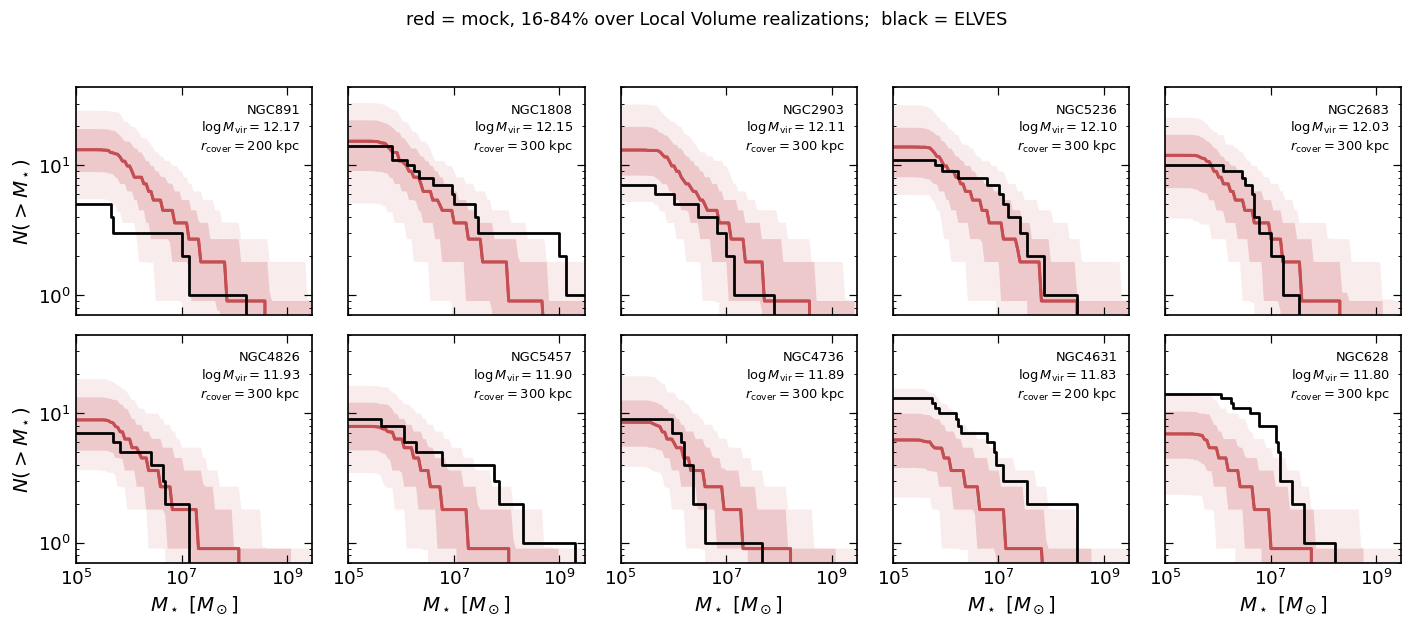

In [10]:
def smf_obs(name):
    return np.array([(obs[name] >= g).sum() for g in GRID])

fig, axes = plt.subplots(2, 5, figsize=(13.0, 5.8), sharex=True, sharey=True)
for ax, (_, host) in zip(axes.ravel(), sample.iterrows()):
    name = host["name"]
    pl.plot_band(ax, GRID, per_host[name], color=C_MOCK, lw=1.8)
    pl.plot_band(ax, GRID, per_host[name], color=C_MOCK, alpha=0.1, percentiles=(2.5, 50, 97.5))
    ax.step(GRID, smf_obs(name), where="post", color=C_OBS, lw=1.8)
    ax.set(xscale="log", yscale="log", xlim=(1e5, 3e9), ylim=(0.7, 40))
    ax.text(0.95, 0.93, f"{name}\n"
                        fr"$\log M_{{\rm vir}}={host.lgmh:.2f}$" "\n"
                        fr"$r_{{\rm cover}}={host.r_cover:.0f}$ kpc",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5)
for ax in axes[-1]:
    ax.set_xlabel(r"$M_\star\ [M_\odot]$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$N(>M_\star)$")
fig.suptitle("red = mock, 16-84% over Local Volume realizations;  black = ELVES", fontsize=11.5)
fig.tight_layout(rect=[0, 0, 1, 0.95])

print(f"{'host':>9}{'mock':>7}{'16-84%':>14}{'ELVES':>7}{'pctile':>8}")
for _, host in sample.iterrows():
    n, k = at(5.7, per_host[host["name"]]), int((obs[host["name"]] > 10 ** 5.7).sum())
    print(f"{host['name']:>9}{np.median(n):7.1f}"
          f"{f'[{np.percentile(n,16):.0f}, {np.percentile(n,84):.0f}]':>14}{k:7d}"
          f"{(n < k).mean():8.2f}")

For many hosts, the agreement is quite good. A few hosts are at $\sim 2\sigma$ range of the prediction. 

---
## 7.4 Stacked

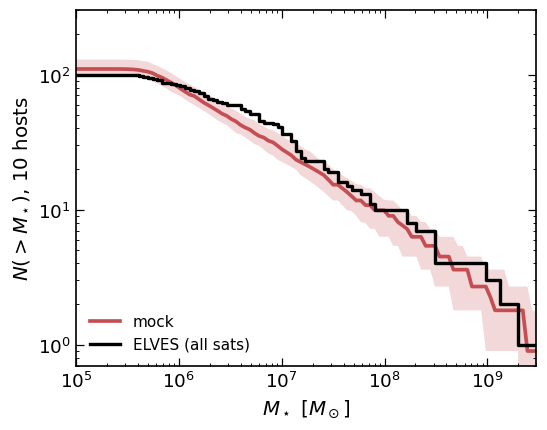

In [11]:
cum_obs = np.array([(np.concatenate(list(obs.values())) >= g).sum() for g in GRID])

fig, ax = plt.subplots(figsize=(5.4, 4.2))
pl.plot_band(ax, GRID, stack, color=C_MOCK, lw=2.4, label="mock")
ax.step(GRID, cum_obs, where="post", color=C_OBS, lw=2.2, label=f"ELVES (all sats)")
ax.set(xscale="log", yscale="log", xlim=(1e5, 3e9), ylim=(0.7, 300),
       xlabel=r"$M_\star\ [M_\odot]$",
       ylabel=fr"$N(>M_\star)$, {len(sample)} hosts")
ax.legend(loc="lower left", fontsize=10)
# fig.tight_layout()

---
## 7.5 The SHMR slope

Let's try to tune the SHMR slope and see how the satellite stellar mass function changes. 
We would expect that steeper SHMR, flatter satellite counts, so shallower mass function.

**The likelihood.** Bin the satellites in $\log M_\star$ above a limit $M_{\rm min}$. If the model
predicts a mean $\lambda_j(\alpha)$ in bin $j$ — the mean over Local Volume realizations, which
already carries the halo-mass draw, the sightline and the selection — and the survey found $n_j$,
the counts are Poisson and

$$\ln L(\alpha)=\sum_j\left[\,n_j\ln\lambda_j(\alpha)-\lambda_j(\alpha)\,\right] + \text{const},$$

with $-\sum_j\ln n_j!$ dropped since it does not depend on $\alpha$. Bins hold equal observed
counts, which with ~50 satellites is the least arbitrary choice and keeps the fit stable as
$M_{\rm min}$ moves.

In [12]:
# alpha only relabels the subhalos, so the geometry of 7.2 is reused: one stacked
# prediction per alpha, cached here and reused by every fit below.
ALPHA_SCAN = np.arange(1.70, 3.05, 0.05)
stacks = {a: realize({n: host_curves(n, a) for n in sample.name})[0] for a in ALPHA_SCAN}

def bin_edges(m_min, n_bins=3):
    # Equal-occupancy bins in log Mstar, from m_min to the top of the grid.
    x = np.log10(np.concatenate(list(obs.values())))
    x = np.sort(x[x >= np.log10(m_min)])
    inner = np.quantile(x, np.linspace(0, 1, n_bins + 1)[1:-1])
    return np.concatenate([[np.log10(m_min)], inner, [np.log10(GRID[-1])]])

def bin_counts(cumulative, edges):
    # Differential counts from a cumulative N(>Mstar) curve on GRID.
    k = [np.argmin(np.abs(np.log10(GRID) - e)) for e in edges]
    return np.stack([cumulative[..., k[i]] - cumulative[..., k[i + 1]]
                     for i in range(len(edges) - 1)], axis=-1)

def poisson_lnlike(n_obs, lam):
    # sum_j [ n_j ln lambda_j - lambda_j ], constant dropped.
    return np.sum(n_obs * np.log(np.maximum(lam, 1e-9)) - lam)

The fit itself: evaluate $\ln L$ on the $\alpha$ grid, then put a parabola through the peak —
$\Delta\ln L=-0.5$ gives the $1\sigma$ width.

In [17]:
def fit_alpha(m_min, n_bins=3):
    edges = bin_edges(m_min, n_bins)
    n_obs = bin_counts(cum_obs, edges)
    lnL = np.array([poisson_lnlike(n_obs, bin_counts(stacks[a], edges).mean(axis=0))
                    for a in ALPHA_SCAN])
    i = np.argmax(lnL)
    j = slice(max(i - 4, 0), i + 5)
    c = np.polyfit(ALPHA_SCAN[j], lnL[j], 2)
    return dict(alpha=-c[1] / (2 * c[0]), err=np.sqrt(-1 / (2 * c[0])),
                lnL=lnL, edges=edges, n_obs=n_obs)

M_MIN = 10 ** 6.5
best = fit_alpha(M_MIN)

print(f"bin edges (log Mstar) : {np.round(best['edges'], 2)}")
print(f"observed counts       : {best['n_obs']}  (total {best['n_obs'].sum()})")
print(f"\n{'alpha':>7}{'predicted counts':>22}{'lnL - max':>12}")
for a in np.arange(1.9, 2.65, 0.1):
    k = np.argmin(np.abs(ALPHA_SCAN - a))
    lam = bin_counts(stacks[ALPHA_SCAN[k]], best["edges"]).mean(axis=0)
    print(f"{ALPHA_SCAN[k]:7.2f}{np.array2string(lam, precision=1):>22}"
          f"{best['lnL'][k] - best['lnL'].max():12.2f}")
print(f"\nalpha = {best['alpha']:.2f} +- {best['err']:.2f}      Danieli+23: 2.10 +- 0.01")

bin edges (log Mstar) : [ 6.5   6.98  7.43 10.2 ]
observed counts       : [18 22 19]  (total 59)

  alpha      predicted counts   lnL - max
   1.90      [22.2 15.1 16. ]       -0.39
   2.00      [21.2 14.9 17. ]       -0.15
   2.10      [20.3 14.8 17.8]       -0.00
   2.20      [19.5 14.6 18.6]        0.00
   2.30      [18.8 14.2 19.4]       -0.15
   2.40      [17.9 14.  20.2]       -0.28
   2.50      [17.3 13.8 20.7]       -0.47
   2.60      [16.7 13.5 21.4]       -0.74

alpha = 2.16 +- 0.32      Danieli+23: 2.10 +- 0.01


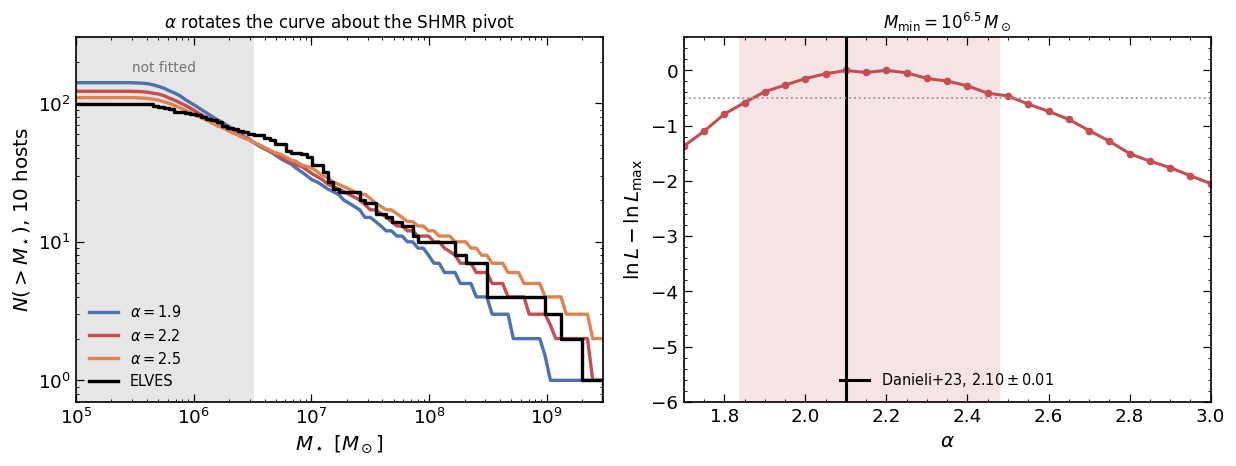

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))

ax = axes[0]
for a, col in [(1.9, "#4C72B0"), (2.2, C_MOCK), (2.5, "#DD8452")]:
    k = np.argmin(np.abs(ALPHA_SCAN - a))
    ax.plot(GRID, np.median(stacks[ALPHA_SCAN[k]], axis=0), color=col, lw=2.2,
            label=fr"$\alpha={a}$")
ax.step(GRID, cum_obs, where="post", color=C_OBS, lw=2.2, label="ELVES")
ax.axvspan(1e5, M_MIN, color="0.9", zorder=0)
ax.text(10 ** 5.75, 170, "not fitted", fontsize=9, color="0.45", ha="center")
ax.set(xscale="log", yscale="log", xlim=(1e5, 3e9), ylim=(0.7, 300),
       xlabel=r"$M_\star\ [M_\odot]$", ylabel=fr"$N(>M_\star)$, {len(sample)} hosts")
ax.legend(loc="lower left", fontsize=9.5)
ax.set_title(r"$\alpha$ rotates the curve about the SHMR pivot", fontsize=11)

ax = axes[1]
ax.plot(ALPHA_SCAN, best["lnL"] - best["lnL"].max(), "o-", color=C_MOCK, ms=4)
ax.axvspan(best["alpha"] - best["err"], best["alpha"] + best["err"],
           color=C_MOCK, alpha=0.15, lw=0)
ax.axvline(2.10, color=C_OBS, lw=2, label=r"Danieli+23, $2.10\pm0.01$")
ax.axhline(-0.5, color="0.6", ls=":", lw=1.2)
ax.set(xlabel=r"$\alpha$", ylabel=r"$\ln L - \ln L_{\rm max}$", xlim=(1.7, 3.0), ylim=(-6, 0.6))
ax.legend(loc="lower center", fontsize=9.5)
ax.set_title(fr"$M_{{\rm min}} = 10^{{6.5}}\,M_\odot$", fontsize=11)
fig.tight_layout()